In [1]:
# Import dependencies
import os
import numpy as np
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.utils import img_to_array, array_to_img

2026-07-06 06:38:34.605333: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-06 06:38:34.753230: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-07-06 06:38:34.753264: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-07-06 06:38:35.403959: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2026-

In [2]:
# from tensorflow.keras import mixed_precision

# # Set up mixed precision policies
# policy = mixed_precision.Policy('mixed_float16')
# mixed_precision.set_global_policy(policy)

## Select GPU and allow memory growth

```set_memory_growth = True``` allows for dynamic GPU memory allocation

In [3]:
# Select GPU we want to use
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Set memory growth
physical_devices = tf.config.list_physical_devices('GPU') 
for gpu_instance in physical_devices: 
    tf.config.experimental.set_memory_growth(gpu_instance, True)
    

2026-07-06 06:38:36.257860: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-07-06 06:38:36.257905: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2026-07-06 06:38:36.257963: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:163] no NVIDIA GPU device is present: /dev/nvidia0 does not exist


## Get cifar10 dataset from keras

This is a dataset of 50,000 32x32 color training images and 10,000 test images, labeled over 10 categories. 

<table>
<thead>
<tr>
<th align="center">Label</th>
<th>Description</th>
</tr>
</thead>
<tbody>
<tr>
<td align="center">0</td>
<td>airplane</td>
</tr>
<tr>
<td align="center">1</td>
<td>car</td>
</tr>
<tr>
<td align="center">2</td>
<td>bird</td>
</tr>
<tr>
<td align="center">3</td>
<td>cat</td>
</tr>
<tr>
<td align="center">4</td>
<td>deer</td>
</tr>
<tr>
<td align="center">5</td>
<td>dog</td>
</tr>
<tr>
<td align="center">6</td>
<td>frog</td>
</tr>
<tr>
<td align="center">7</td>
<td>horse</td>
</tr>
<tr>
<td align="center">8</td>
<td>ship</td>
</tr>
<tr>
<td align="center">9</td>
<td>truck</td>
</tr>
</tbody>
</table>

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
# we check the dataset shape
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

In [5]:
# Dictionary containg the sematic classes
label_dict = {0:"airplane", 1:"car", 2:"bird", 3:"cat", 4:"deer", 5:"dog", 6:"frog", 7:"horse", 8:"ship", 9:"truck"}

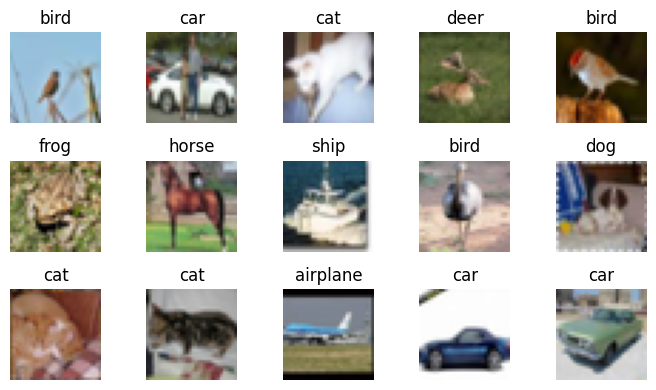

In [6]:
# Show 15 example images from test dataset.
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(7, 4))
ax = axes.ravel()

ids = np.random.randint(1, 10000, size=15)
for i, j in enumerate(ids):
    
    ax[i].imshow(x_test[j])
    ax[i].set_title(label_dict[y_test[j][0]])
    ax[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
### choose part of the image to reduce calculation time
ids = np.random.randint(1, 50000, size=5000)
x_train, y_train = x_train[ids], y_train[ids]

ids = np.random.randint(1, 10000, size=1000)
x_test, y_test = x_test[ids], y_test[ids]

### check range of image intensity and normalize  

In [8]:
print(np.min(x_train), np.max(x_train))

x_train = x_train / 255.
x_test = x_test / 255.

print(np.min(x_train), np.max(x_train))

0 255
0.0 1.0


### Machine Learning based classification

In [9]:
! pip install SimpleITK
! pip install pyradiomics
import SimpleITK as sitk

from radiomics import featureextractor

  Using cached simpleitk-2.5.5-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (52.8 MB)
  Using cached pyradiomics-3.1.0.tar.gz (34.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Discarding https://files.pythonhosted.org/packages/03/c1/20fc2c50ab1e3304da36d866042a1905a2b05a1431ece35448ab6b4578f2/pyradiomics-3.1.0.tar.gz (from https://pypi.org/simple/pyradiomics/): Requested pyradiomics from https://files.pythonhosted.org/packages/03/c1/20fc2c50ab1e3304da36d866042a1905a2b05a1431ece35448ab6b4578f2/pyradiomics-3.1.0.tar.gz has inconsistent version: expected '3.1.0', but metadata has '3.0.1a1'
  Using cached pyradiomics-3.0.1-cp310-cp310-linux_x86_64.whl
  Using cached pykwalify-1.8.0-py2.py3-none-any.whl (24 kB)
  Using cached docopt-0.6.2-py2.py3-none-any.whl


In [10]:
# import warnings

# def fxn():
#     warnings.warn("deprecated", DeprecationWarning)

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     fxn()
import logging
logger = logging.getLogger("radiomics.glcm")
logger.setLevel(logging.ERROR)

In [11]:
from tqdm import tqdm

In [12]:
extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.disableAllFeatures()
extractor.enableFeatureClassByName('firstorder')
extractor.enableFeatureClassByName('glcm') 
im_shape = x_train.shape

mask = np.ones(im_shape[1:])
mask = sitk.GetImageFromArray(mask)

features_train = []
for i in tqdm(range(im_shape[0])):
    
    features = extractor.computeFeatures(sitk.GetImageFromArray(x_train[i, :, :, :]), mask, 'original')
    features_all = []
    for featureName in features.keys():
        val = features[featureName]
        features_all = np.append(features_all, val/(1e-8+np.max(val)))
        
    features_train.append(features_all)

features_train = np.row_stack(features_train)
features_train.shape


100%|██████████| 5000/5000 [00:29<00:00, 172.09it/s]


(5000, 42)

In [13]:
features_test = []
for i in tqdm(range(x_test.shape[0])):
    
    features = extractor.computeFeatures(sitk.GetImageFromArray(x_test[i, :, :, :]), mask, 'original')
    features_all = []
    for featureName in features.keys():
        val = features[featureName]
        features_all = np.append(features_all, val/(1e-8+np.max(val)))
        
    features_test.append(features_all)
features_test = np.row_stack(features_test)
features_test.shape

100%|██████████| 1000/1000 [00:05<00:00, 171.76it/s]


(1000, 42)

In [14]:
### build classification model with Linear discriminant analysis

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

model_LDA = LDA().fit(features_train, y_train)
y_pred = model_LDA.predict(features_test)

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:1111: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [15]:
from sklearn.metrics import confusion_matrix
cmat = confusion_matrix(y_test, y_pred)
cmat

array([[44, 15,  8,  4, 21,  6,  0,  0,  3,  8],
       [14, 46,  1,  2,  9, 19,  0,  0,  2, 25],
       [22, 13, 13,  4, 48, 11,  1,  0,  3, 10],
       [17, 21,  7,  1, 21, 13,  0,  0,  5,  8],
       [11, 10,  7,  1, 50,  4,  0,  0,  4,  3],
       [17, 15,  3,  8, 21, 13,  0,  0,  4, 15],
       [ 6, 14,  6,  4, 31, 10,  0,  0,  4,  9],
       [14, 12,  6,  7, 20, 14,  0,  0,  5, 14],
       [22, 17,  7,  3, 16,  9,  0,  0, 10, 17],
       [10, 24,  1,  2,  5,  8,  0,  0, 11, 31]])

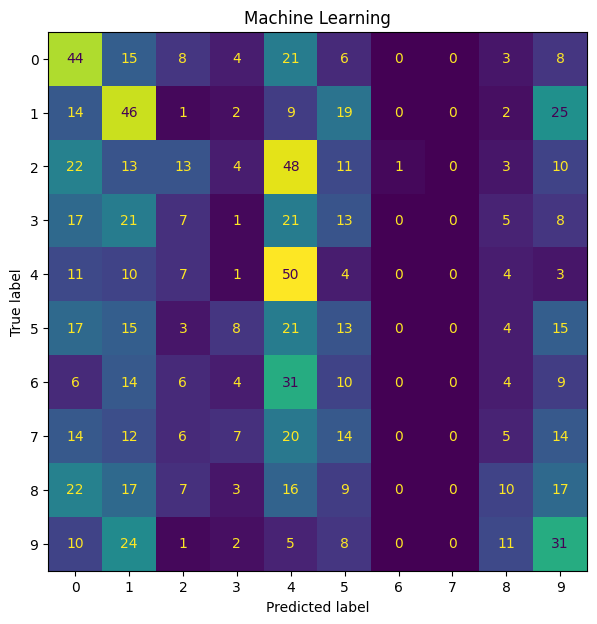

In [16]:
### display confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cmat, display_labels=np.unique(y_train))
    
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
disp.plot(ax=ax, colorbar=False)
plt.title('Machine Learning')
plt.show()

In [17]:
# Define a simple model using keras sequential

def gen_model(input_size, output_size):
    
    model = tf.keras.Sequential([
            keras.Input(shape=input_size),   # set input shape
        
            keras.layers.Conv2D(64, 3),      # include 2D convolutions, conv2d(n_kernels, size)
            keras.layers.Conv2D(64, 3),
            keras.layers.Conv2D(64, 3),
        
            keras.layers.Flatten(),          # reshape to 1D vector
        
            keras.layers.Dense(256, activation='relu'),  # Dense layer with 256 outputs, no linear activation
            keras.layers.Dense(output_size, activation='softmax')  # output layer with 10 outputs
        ])
    return model

In [18]:
input_size = (32, 32, 3)
output_size = 10
learning_rate = 0.001

model = gen_model(input_size, output_size)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), 
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['sparse_categorical_accuracy'])

2026-07-06 06:39:30.738498: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [19]:
model.fit(x_train, y_train, 
          batch_size=None,
          epochs=10,
          verbose=1,     # 0-no output, 1-progress bar, 2-one line per epoch
          validation_data=None,
          validation_split=0.2,
          callbacks=None,
          shuffle=True
         )

Epoch 1/10
125/125 [==============================] - 41s 323ms/step - loss: 2.6023 - sparse_categorical_accuracy: 0.2575 - val_loss: 1.9115 - val_sparse_categorical_accuracy: 0.3250
Epoch 2/10
125/125 [==============================] - 39s 310ms/step - loss: 1.7199 - sparse_categorical_accuracy: 0.4038 - val_loss: 1.8530 - val_sparse_categorical_accuracy: 0.3490
Epoch 3/10
125/125 [==============================] - 39s 309ms/step - loss: 1.5013 - sparse_categorical_accuracy: 0.4820 - val_loss: 1.9634 - val_sparse_categorical_accuracy: 0.3580
Epoch 4/10
125/125 [==============================] - 38s 305ms/step - loss: 1.2114 - sparse_categorical_accuracy: 0.5860 - val_loss: 1.9855 - val_sparse_categorical_accuracy: 0.3800
Epoch 5/10
125/125 [==============================] - 39s 311ms/step - loss: 0.8418 - sparse_categorical_accuracy: 0.7122 - val_loss: 2.2633 - val_sparse_categorical_accuracy: 0.3650
Epoch 6/10
125/125 [==============================] - 39s 308ms/step - loss: 0.5481 -

In [20]:
prediction = model.predict(x_test)
print("prediction shape : ", np.shape(prediction))

prediction_class = np.argmax(prediction, axis=-1)
print("prediction_class shape", np.shape(prediction_class))

32/32 [==============================] - 1s 37ms/step
prediction shape :  (1000, 10)
prediction_class shape (1000,)


In [21]:
cmat_DL = confusion_matrix(y_test, prediction_class)
cmat_DL

array([[34, 10,  9,  1,  4,  2,  5, 10, 29,  5],
       [ 5, 59,  5,  5,  5,  3,  6,  3,  6, 21],
       [ 6,  7, 23, 21, 18, 13,  5, 19,  8,  5],
       [ 6,  5, 12, 15, 10, 17, 15,  9,  2,  2],
       [ 5,  2, 17,  4, 27,  6, 11, 16,  1,  1],
       [ 2,  2,  5, 19, 21, 26,  6, 12,  3,  0],
       [ 1,  0,  9,  9, 11, 13, 29,  9,  2,  1],
       [ 4,  4,  8,  4,  5,  7,  8, 48,  1,  3],
       [18, 19,  4,  6,  3,  5,  0,  4, 40,  2],
       [ 8, 24,  4,  3,  4,  3,  4,  7, 12, 23]])

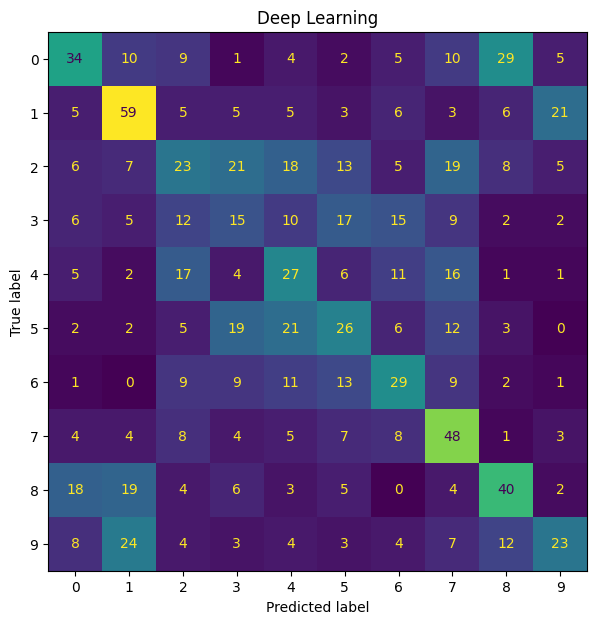

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cmat_DL, display_labels=np.unique(y_train))
    
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
disp.plot(ax=ax, colorbar=False)
plt.title('Deep Learning')
plt.show()